# Validation Pipeline Sketch V1

## 0. Imports and Set-Up:

In [342]:
import multiprocessing
# import sys
# import logging
from joblib import dump, load

import numpy as np
import pandas as pd

from typing import Type, Any, Optional
from pathlib import Path

from sklearn.base import ClusterMixin
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, jaccard_score, f1_score, confusion_matrix, silhouette_score, pairwise_distances
from sklearn.utils import check_random_state
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import ParameterSampler

from scipy.optimize import linear_sum_assignment
from scipy.stats import gaussian_kde, multivariate_normal
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

import scanpy as sc

# from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from tqdm.auto import tqdm

from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [ ]:
def plot_dim_reduces_clustering(X: np.ndarray, clusters: np.ndarray, method: str = 'PCA') -> None:
    if method == 'PCA':
        pca = PCA(n_components=2, random_state=RANDOM_SEED)
        X_red = pca.fit_transform(X)   
    elif method == 'tSNE':
        tsne = TSNE(n_components=2, random_state=RANDOM_SEED, verbose=1, perplexity=30)
        X_red = tsne.fit_transform(X)
    else:
        raise ValueError(f"Unknown method {method}. Use one of 'PCA' or 'tSNE'.")
        
    
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(
        X_red[:, 0], X_red[:, 1],
        c=clusters,
        s=10,
        alpha=0.8
    )
        
    legend1 = ax.legend(
        *scatter.legend_elements(),
        title="cluster",
        loc='lower right',
        frameon=False
    )
    ax.add_artist(legend1)

    ax.set_title("PCA of TCGA Pan-Cancer gene expression")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    plt.tight_layout()
    plt.show()

### 0.1 Data Import:

In [45]:
data_dir = Path('./data/TCGA-PANCAN-HiSeq-801x20531')
data_fp = data_dir / 'data.csv'
labels_fp = data_dir / 'labels.csv'

In [46]:
labels = pd.read_csv(labels_fp, header=None, skiprows=1)

In [47]:
sample = pd.read_csv(data_fp, header=None, skiprows=1, nrows=100, low_memory=False)

numeric_cols = [
    col
    for col in sample.columns
    if pd.to_numeric(sample[col], errors='coerce').notna().all()
]

print(f"found {len(numeric_cols)} numeric cols out of {len(sample.columns)}")

data = pd.read_csv(
    data_fp,
    header=None,
    usecols=numeric_cols,
    skiprows=1, 
    dtype=float,
    low_memory=False
)

print(data.shape)

found 20531 numeric cols out of 20532
(801, 20531)


In [48]:
le = LabelEncoder()
y = le.fit_transform(labels[1])

X = data.values

In [49]:
np.unique(y)

array([0, 1, 2, 3, 4])

In [50]:
print("X shape:", X.shape, " |  y shape:", y.shape)

X shape: (801, 20531)  |  y shape: (801,)


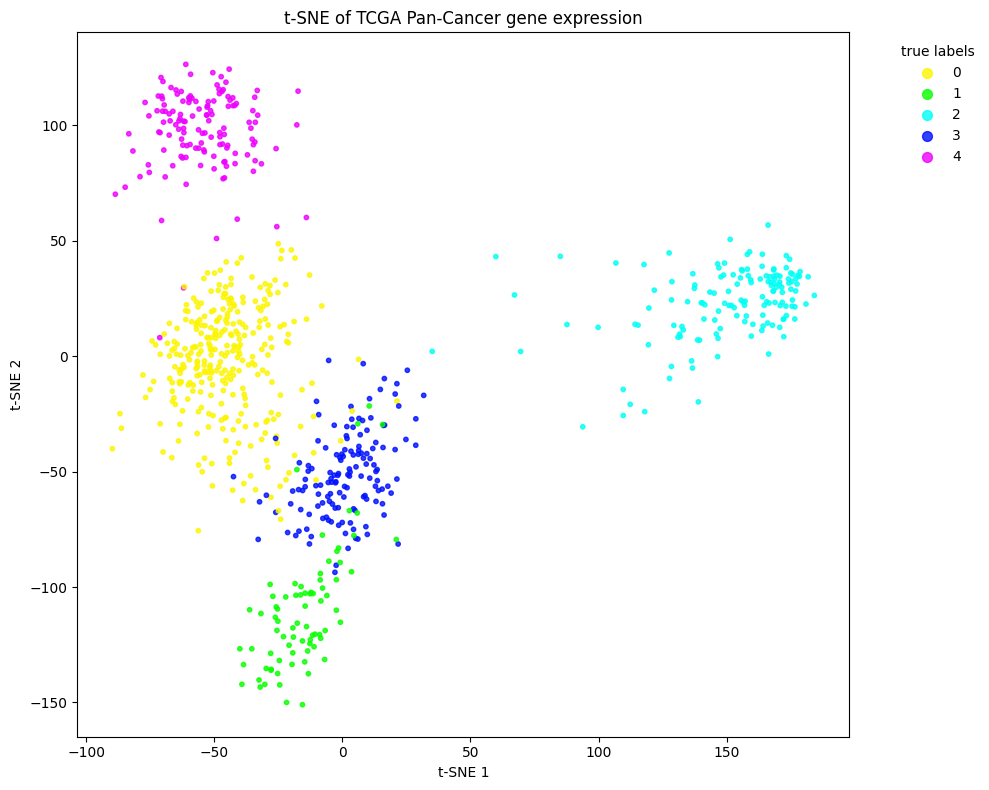

In [283]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X)   

unique_labels = np.unique(y)
n_labels = len(unique_labels)
palette = sns.color_palette("hsv", n_labels)
color_dict = {lab: palette[i] for i, lab in enumerate(unique_labels)}
colors = [color_dict[lab] for lab in y]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=colors,
    s=10,
    alpha=0.8
)

for lab in unique_labels:
    ax.scatter([], [], c=[color_dict[lab]], label=str(lab), s=50, alpha=0.8)
ax.legend(
    title="true labels",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=1,
    frameon=False
)

ax.set_title("t-SNE of TCGA Pan-Cancer gene expression")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 801 samples in 0.049s...
[t-SNE] Computed neighbors for 801 samples in 0.163s...
[t-SNE] Computed conditional probabilities for sample 801 / 801
[t-SNE] Mean sigma: 51.650639
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.111629
[t-SNE] KL divergence after 1000 iterations: 0.682923


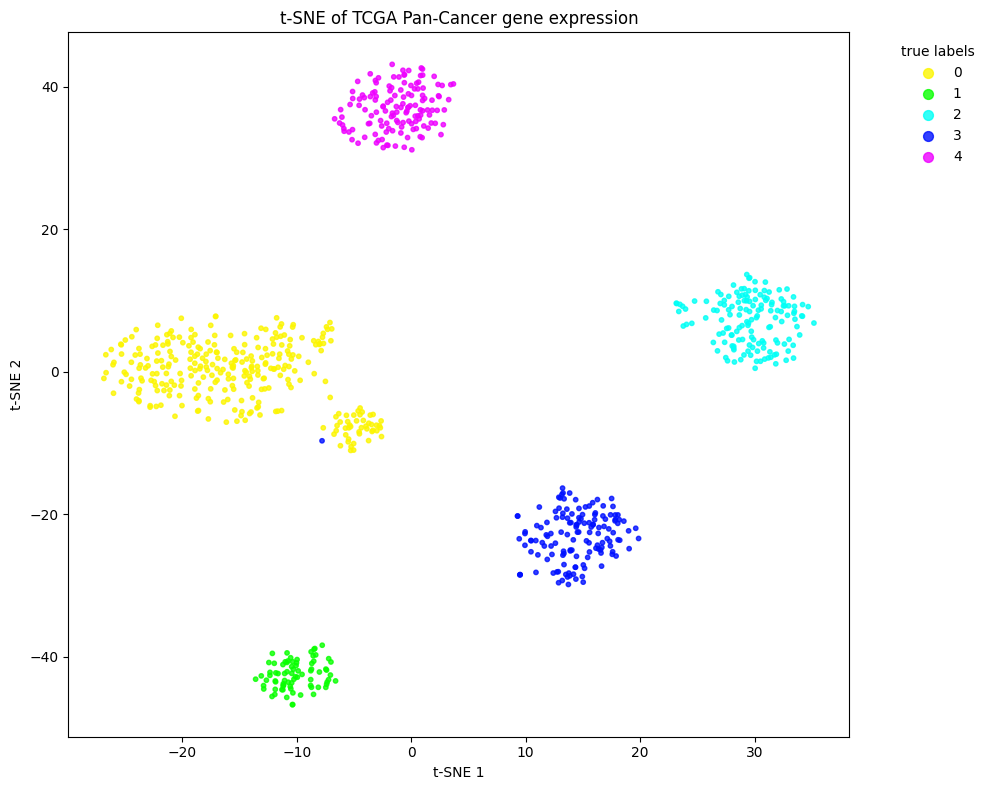

In [281]:
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, verbose=1, perplexity=30)
X_tsne = tsne.fit_transform(X)

unique_labels = np.unique(y)
n_labels = len(unique_labels)
palette = sns.color_palette("hsv", n_labels)
color_dict = {lab: palette[i] for i, lab in enumerate(unique_labels)}
colors = [color_dict[lab] for lab in y]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=colors,
    s=10,
    alpha=0.8
)

for lab in unique_labels:
    ax.scatter([], [], c=[color_dict[lab]], label=str(lab), s=50, alpha=0.8)
ax.legend(
    title="true labels",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=1,
    frameon=False
)

ax.set_title("t-SNE of TCGA Pan-Cancer gene expression")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

### 0.2 Synthetic Data:

In [9]:
def generate_gaussian_mixture(
    n_samples: int, 
    pi1: float = 0.5, 
    sigma: float = 0.15, 
    mu1: Optional[np.ndarray] = None, 
    mu2: Optional[np.ndarray] = None, 
    seed: Optional[int] = None
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate 2D Gaussian mixture data and compute ground-truth soft labels.

    :param n_samples: number of samples to generate.
    :param sigma: standard deviation of the isotropic Gaussians.
    :param seed: optional random seed.
    
    :return: 
        X: (n_samples, 2) data matrix
        soft_labels: (n_samples, 2) matrix of posterior probabilities
    """
    if seed is not None:
        np.random.seed(seed)

    # Define component means on unit circle
    if mu1 is None:
        mu1 = np.array([1.0, 0.0])
    
    if mu2 is None:
        mu2 = np.array([-1.0, 0.0])
    
    # Mixing proportions
    pi2 = 1 - pi1

    # Covariance matrix (isotropic)
    cov = (sigma ** 2) * np.eye(2)

    # Sample component labels (0 or 1)
    labels = np.random.choice([0, 1], size=n_samples, p=[pi1, pi2])

    # Generate samples
    X = np.array([
        np.random.multivariate_normal(mu1, cov) if label == 0 else
        np.random.multivariate_normal(mu2, cov)
        for label in labels
    ])

    # Compute posterior probabilities
    phi1 = multivariate_normal.pdf(X, mean=mu1, cov=cov)
    phi2 = multivariate_normal.pdf(X, mean=mu2, cov=cov)
    denom = pi1 * phi1 + pi2 * phi2

    theta1 = (pi1 * phi1) / denom
    theta2 = 1.0 - theta1

    soft_labels = np.vstack((theta1, theta2)).T

    return X, soft_labels

In [11]:
X, soft_labels = generate_gaussian_mixture(n_samples=500, sigma=0.5, seed=42)
print("Data shape:", X.shape)
print("Soft labels shape:", soft_labels.shape)
print("First 10 soft labels:\n", soft_labels[: 10])

Data shape: (500, 2)
Soft labels shape: (500, 2)
First 10 soft labels:
 [[9.99914510e-01 8.54901497e-05]
 [1.47987292e-02 9.85201271e-01]
 [9.22431238e-06 9.99990776e-01]
 [1.70672448e-06 9.99998293e-01]
 [9.99997003e-01 2.99740549e-06]
 [7.59047014e-01 2.40952986e-01]
 [9.99469861e-01 5.30139224e-04]
 [5.69953416e-07 9.99999430e-01]
 [3.42455884e-04 9.99657544e-01]
 [5.54340062e-05 9.99944566e-01]]


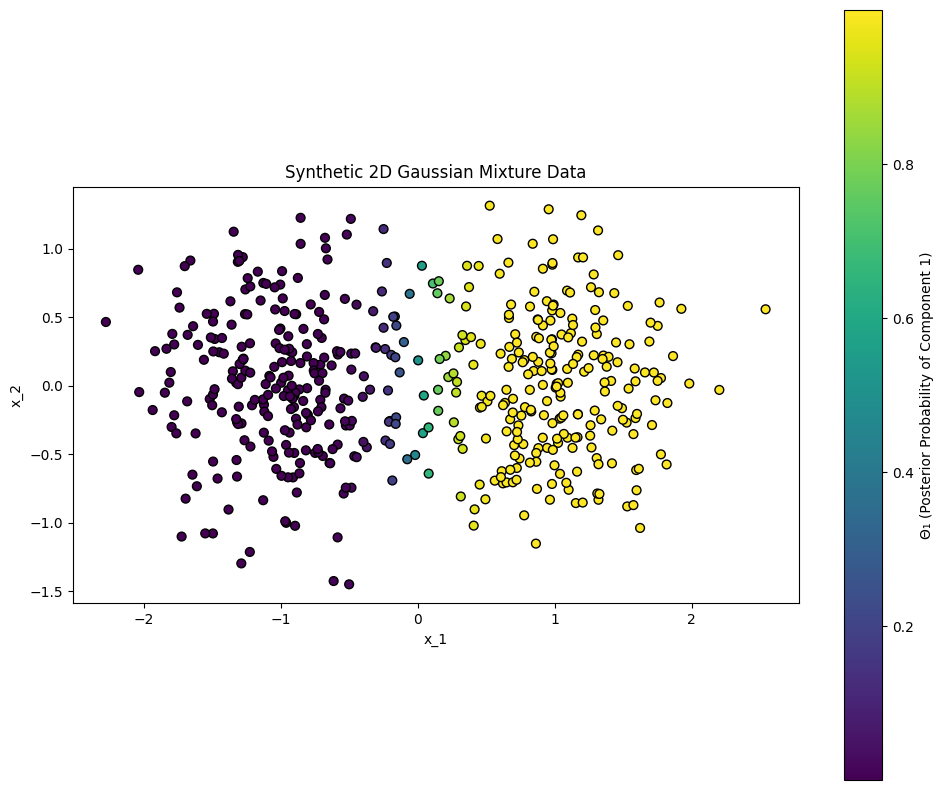

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X[:, 0], X[:, 1], c=soft_labels[:, 0], cmap='viridis', s=40, edgecolors='k')

cbar = fig.colorbar(scatter, ax=ax, label='Θ₁ (Posterior Probability of Component 1)')

ax.set_title("Synthetic 2D Gaussian Mixture Data")
ax.set_xlabel("x_1")
ax.set_ylabel("x_2")
# ax.grid(True)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---

# 1. Different Values of K

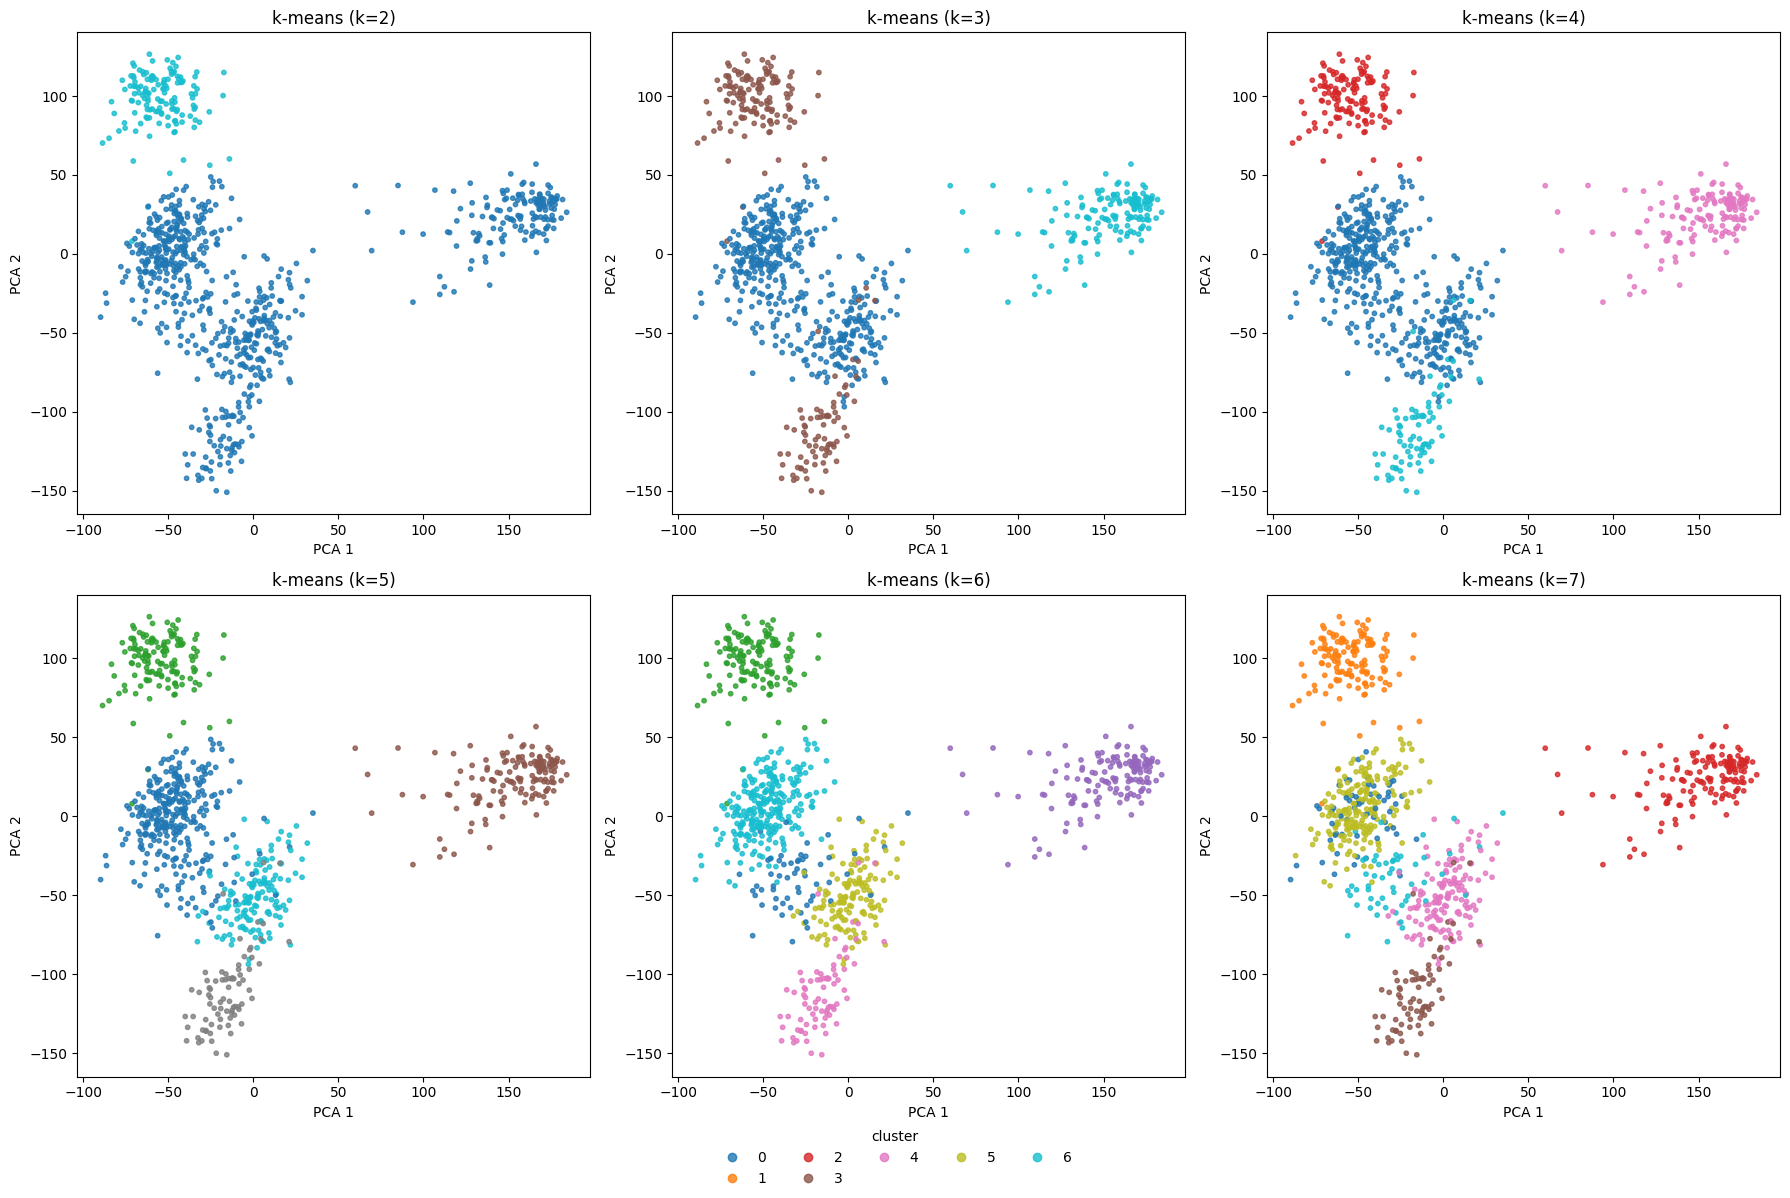

In [52]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X)

ks = [2, 3, 4, 5, 6, 7]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, k in zip(axes, ks):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    clusters = kmeans.fit_predict(X)
    
    scatter = ax.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=clusters,
        s=10,
        alpha=0.8,
        cmap='tab10'
    )
    ax.set_title(f'k-means (k={k})')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')

fig.legend(
    *scatter.legend_elements(),
    title="cluster",
    loc='lower center',
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

---

# 3. ScanPy:
## 3.1 Default Values:

In [287]:
adata = sc.AnnData(X)

Compute a k-nearest-neighbors graph.

- n_neighbors=10: for each cell, find its 10 closest neighbors.
- n_pcs=None: without PCA (s.t. results are comparable to our method below).

resolution parameter controls granularity:
- lower: fewer, larger clusters
- higher: more, smaller clusters

sc.tl.leiden runs the leiden community-detection algorithm (Traag et al., 2019) on the neighbor graph. The Leiden algorithm is an improved version of the Louvain algorithm (Blondel et al., 2008). It was proposed for single-cell analysis by Levine et al. (2015).

In [268]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=None, method='umap', random_state=0)
sc.tl.leiden(adata, resolution=1, random_state=0, key_added='leiden_opt', n_iterations=-1)
labels = adata.obs['leiden_opt'].astype(int)
optimal_k = labels.nunique()
print(f"scanpy-chosen k: k={optimal_k}")

scanpy-chosen k: k=9


In [270]:
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_SEED)
clusters = kmeans.fit_predict(X)

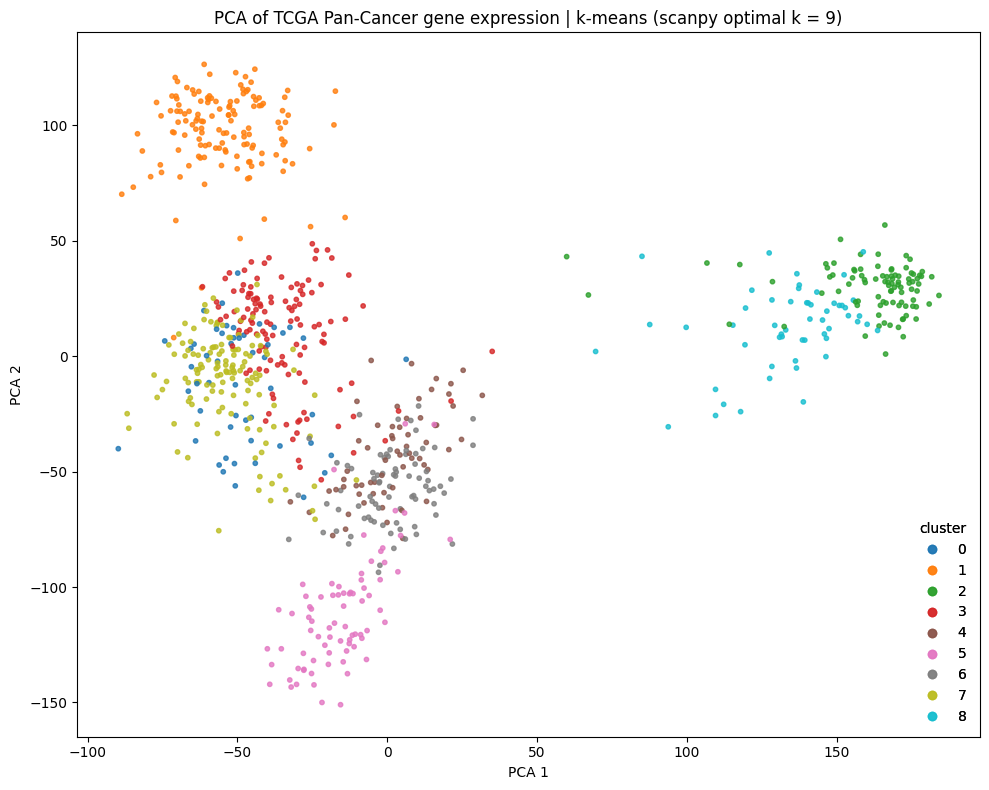

In [273]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=clusters,
    s=10,
    alpha=0.8,
    cmap='tab10'
)
ax.set_title(f'PCA of TCGA Pan-Cancer gene expression | k-means (scanpy optimal k = {optimal_k})')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')

legend1 = ax.legend(
    *scatter.legend_elements(),
    title="cluster",
    loc='lower right',
    frameon=False
)
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 801 samples in 0.054s...
[t-SNE] Computed neighbors for 801 samples in 0.151s...
[t-SNE] Computed conditional probabilities for sample 801 / 801
[t-SNE] Mean sigma: 51.650639
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.111629
[t-SNE] KL divergence after 1000 iterations: 0.682923


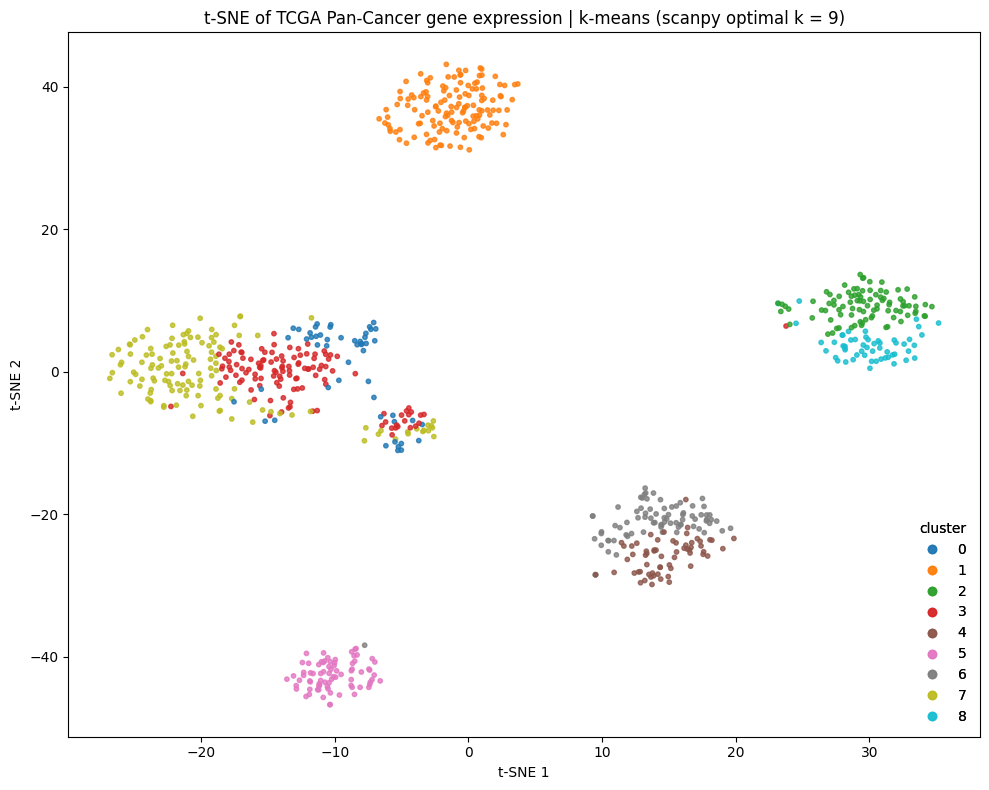

In [274]:
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, verbose=1, perplexity=30)
X_tsne = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=clusters,
    s=10,
    alpha=0.8,
    cmap='tab10'
)
    
legend1 = ax.legend(
    *scatter.legend_elements(),
    title="cluster",
    loc='lower right',
    frameon=False
)
ax.add_artist(legend1)

ax.set_title(f"t-SNE of TCGA Pan-Cancer gene expression | k-means (scanpy optimal k = {optimal_k})")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 3.2 ScanPy Stability Analysis

In [335]:
param_dist = {
    "preproc": ["raw", "normalized", "log1p"],
    "n_neighbors": np.arange(5, 51, 5),
    "n_pcs": np.arange(10, 101, 5),
    "method": ["umap", "gauss"],
    "resolution": np.linspace(0.1, 2.0, 20),
    "random_state":[0, 7, 13, 42, 99]
}

n_iter = 1000
sampler = ParameterSampler(param_dist, n_iter=n_iter, random_state=0)

In [347]:
ref_k = 5
kmeans = KMeans(n_clusters=ref_k, random_state=0).fit(adata.X)
ref_labels = kmeans.labels_

results = []
for params in sampler:
    # preprocessing
    ad = adata.copy()
    if params["preproc"] == "normalized":
        sc.pp.normalize_total(ad)
    elif params["preproc"] == "log1p":
        sc.pp.normalize_total(ad); sc.pp.log1p(ad)
        
    # graph & leiden
    sc.pp.neighbors(ad,
        n_neighbors=params["n_neighbors"],
        n_pcs=params["n_pcs"],
        use_rep='X',
        method=params["method"],
        random_state=params["random_state"]
    )
    sc.tl.leiden(ad,
        resolution=params["resolution"],
        random_state=params["random_state"],
        key_added="leiden_opt", n_iterations=-1
    )
    
    labels_opt = ad.obs["leiden_opt"].astype(int).values
    k_opt = labels_opt.max() + 1
    # compute ARI
    ari = adjusted_rand_score(ref_labels, labels_opt)
    results.append({**params, "k": k_opt, "ari_vs_kmeans": ari})

df = pd.DataFrame(results)

In [317]:
vibrant = sns.color_palette("rainbow", n_colors=8)

sns.set_theme(
    style="whitegrid",
    palette=vibrant,
    font_scale=1.2,
    rc={
        "axes.edgecolor": ".2",
        "grid.color": ".8",
        "grid.linewidth": 0.8,
        "figure.figsize": (8, 5),
        "axes.prop_cycle": plt.cycler(color=vibrant)
    }
)

sns.set_context("notebook", rc={"lines.linewidth": 2, "font.size": 14})

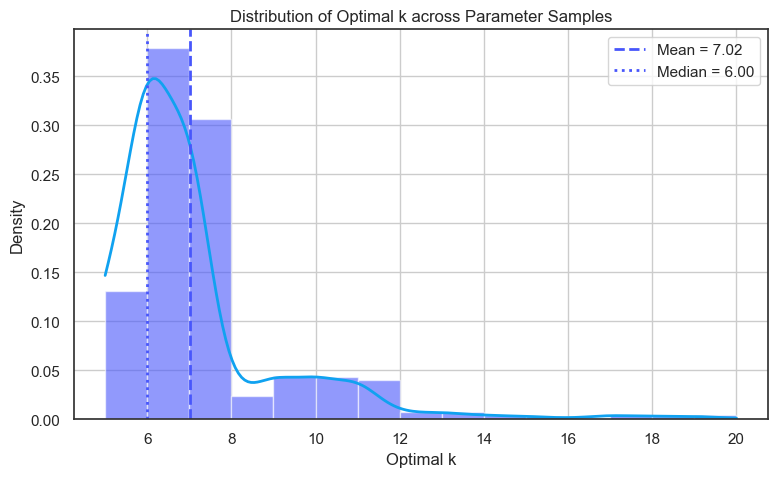

Mean of k: 7.02
Median of k: 6.00
Variance of k: 4.39


In [348]:
k_values = df['k'].values

mean_k = k_values.mean()
median_k = np.median(k_values)
variance_k = k_values.var()

kde = gaussian_kde(k_values)
x_grid = np.linspace(k_values.min(), k_values.max(), 200)

fig, ax = plt.subplots()
ax.hist(k_values, bins='auto', density=True, alpha=0.6)
ax.plot(x_grid, kde(x_grid), linewidth=2)
ax.axvline(mean_k, linestyle='--', label=f"Mean = {mean_k:.2f}")
ax.axvline(median_k, linestyle=':', label=f"Median = {median_k:.2f}")
ax.set_xlabel('Optimal k')
ax.set_ylabel('Density')
ax.set_title('Distribution of Optimal k across Parameter Samples')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean of k: {mean_k:.2f}")
print(f"Median of k: {median_k:.2f}")
print(f"Variance of k: {variance_k:.2f}")

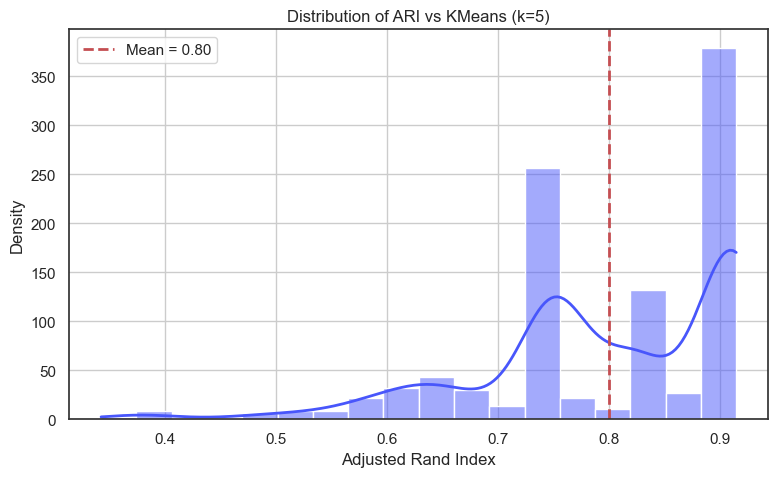

Mean of ARIs: 0.80
Median of ARIs: 0.82
Variance of ARIs: 0.01


In [350]:
ari_values = df['ari_vs_kmeans'].values

mean_k = ari_values.mean()
median_k = np.median(ari_values)
variance_k = ari_values.var()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["ari_vs_kmeans"], kde=True, ax=ax)
ax.axvline(df["ari_vs_kmeans"].mean(), color="r", linestyle="--", label=f"Mean = {df['ari_vs_kmeans'].mean():.2f}")
ax.set_title("Distribution of ARI vs KMeans (k=5)")
ax.set_xlabel("Adjusted Rand Index")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean of ARIs: {mean_k:.2f}")
print(f"Median of ARIs: {median_k:.2f}")
print(f"Variance of ARIs: {variance_k:.2f}")

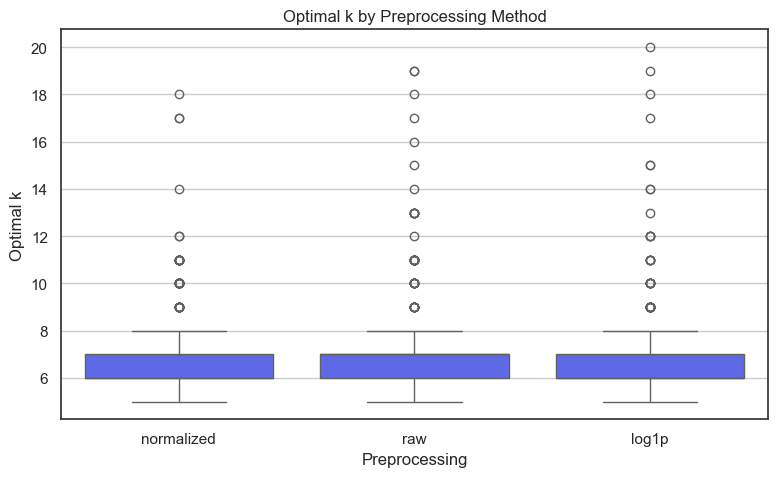

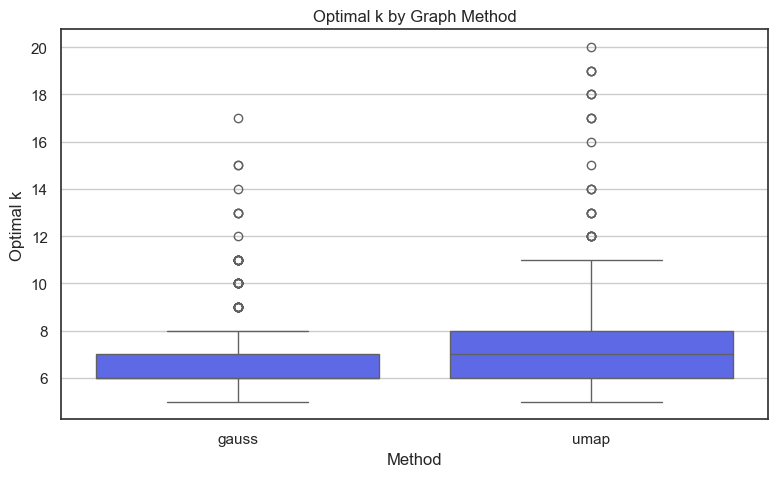

In [338]:
# preprocessing
fig, ax = plt.subplots()
sns.boxplot(x="preproc", y="k", data=df, ax=ax)
ax.set_title("Optimal k by Preprocessing Method")
ax.set_xlabel("Preprocessing")
ax.set_ylabel("Optimal k")
plt.tight_layout()

# method
fig, ax = plt.subplots()
sns.boxplot(x="method", y="k", data=df, ax=ax)
ax.set_title("Optimal k by Graph Method")
ax.set_xlabel("Method") 
ax.set_ylabel("Optimal k")
plt.tight_layout()

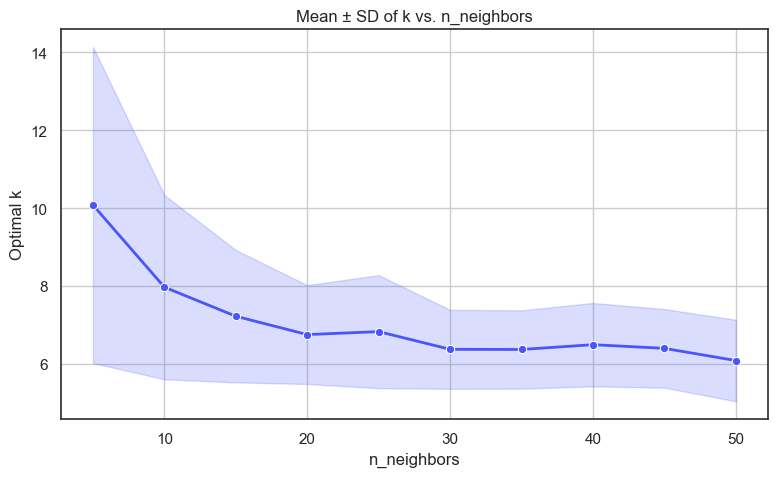

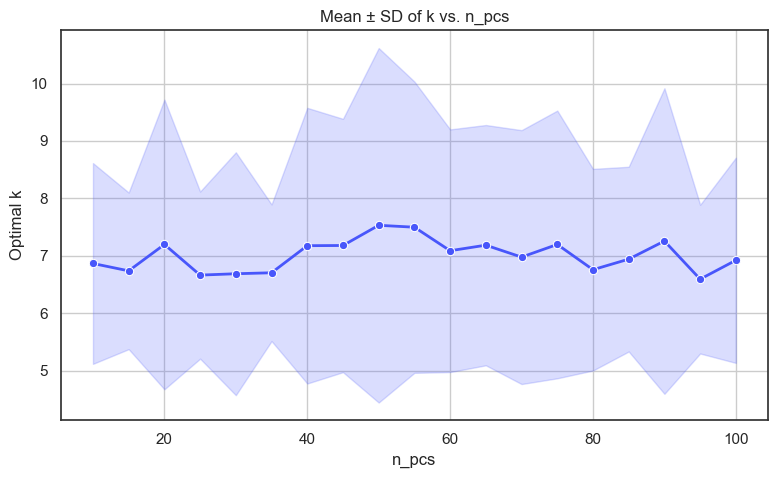

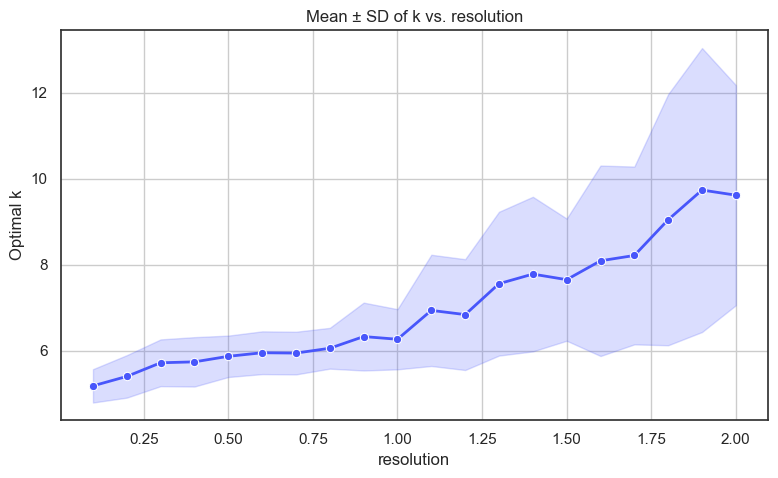

In [339]:
for param in ["n_neighbors", "n_pcs", "resolution"]:
    fig, ax = plt.subplots()

    sns.lineplot(
        x=param, y="k", 
        data=df, 
        estimator="mean", 
        errorbar="sd", 
        marker="o", 
        ax=ax
    )
    ax.set_title(f"Mean ± SD of k vs. {param}")
    ax.set_xlabel(param)
    ax.set_ylabel("Optimal k")
    plt.tight_layout()

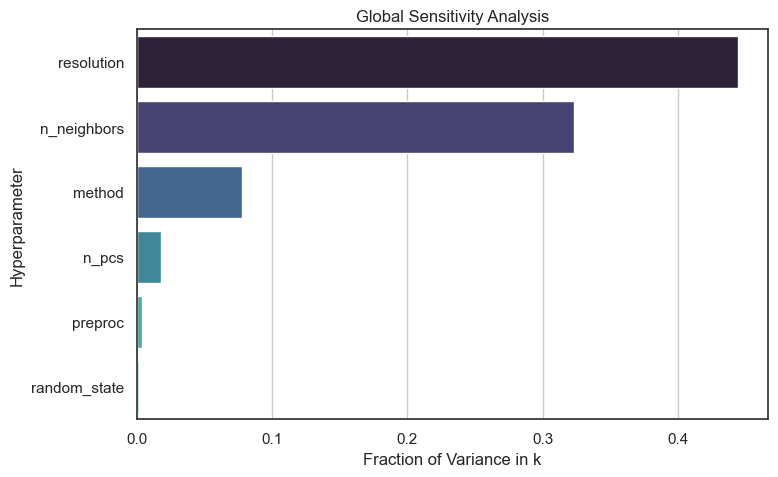

In [341]:
total_var = df["k"].var()
sensi = {
    param: df.groupby(param)["k"].mean().var() / total_var
    for param in ["preproc", "method", "n_neighbors", "n_pcs", "resolution", "random_state"]
}
sensi = pd.Series(sensi).sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=sensi.values, y=sensi.index, palette="mako", hue=sensi.index, ax=ax)
ax.set_xlabel("Fraction of Variance in k")
ax.set_ylabel("Hyperparameter")
ax.set_title("Global Sensitivity Analysis")
plt.tight_layout()

---
## 2. Helper Functions:

In [60]:
def _gen_null(X: np.ndarray, _: int, random_state: int) -> np.ndarray:
    """
    Generate a single null-distribution dataset.

    :param X: reference dataset
    :param _: dummy index for Parallel
    :param random_state: random state for the random number generator
    
    :return: null-distribution dataset of same shape as X
    """
    rng = check_random_state(random_state)
    n_samples, p = X.shape
    
    X_ref = np.empty_like(X)
    for j in range(p):
        X_ref[:, j] = rng.uniform(np.min(X[:, j]), np.max(X[:, j]), size=n_samples)
        
    return X_ref

In [61]:
def subsample_indices(n_samples: int, ratio: float = 0.8, random_state: int = None) -> tuple[np.ndarray, np.ndarray]:
    """
    draw a subsample of indices of size floor(ratio * n_samples).
    
    :param n_samples: total number of samples in data frame.
    :param ratio: ratio for subsampling, between 0 and 1. 
    :param random_state: random seed for rng.
    
    :return:
        train_idx: 1D array of length floor(ratio * n_samples).
        test_idx: the complement indices (length = n_samples - len(train_idx)).
    """
    rng = np.random.RandomState(random_state)
    all_idx = np.arange(n_samples)
    train_size = int(np.float64(ratio * n_samples))
    
    train_idx = rng.choice(all_idx, size=train_size, replace=False)
    test_idx = np.setdiff1d(all_idx, train_idx)
    
    return train_idx, test_idx

In [62]:
def cluster_and_get_labels(X_train: np.ndarray, algorithm: Type[ClusterMixin], **cluster_kwargs) -> tuple[np.ndarray, ClusterMixin]:
    """
    fits 'algorithm' on X_train, returns an array of cluster labels, length = len(X_train).

    :param X_train: numpy array of shape (n_train, n_features)
    :param algorithm: a clustering class or function (e.g., sklearn.cluster.KMeans)
    :param cluster_kwargs: parameters passed to the clustering constructor, e.g. n_clusters=k, random_state, etc.

    :return:
        labels: 1D array of length n_train, cluster assignments (0..k-1)
        fitted_model: the trained clustering object
    """
    model = algorithm(**cluster_kwargs)
    labels = model.fit_predict(X_train)
    
    return labels, model

In [63]:
def train_rf(X_train: np.ndarray, labels_train: np.ndarray, **rf_kwargs) -> RandomForestClassifier:
    """
    trains a random forest classifier to predict cluster labels from features.
    
    :param X_train: numpy array, shape = (n_train, n_features)
    :param labels_train: 1D array of ints (cluster ids)
    :param rf_kwargs: keyword args for RandomForestClassifier, e.g. n_estimators, max_depth, random_state
    
    :return: fitted RandomForestClassifier
    """
    rf_model = RandomForestClassifier(**rf_kwargs)
    rf_model.fit(X_train, labels_train)
    
    return rf_model

In [64]:
def compute_external_metrics(labels_true: np.ndarray, labels_pred: np.ndarray, metric: str = 'ARI') -> dict[str, float]:
    """
    compute ARI, Jaccard score, or FM score (as suggested by Dudoit & Fridlyand (2002) between two label vectors of equal length.
    
    :param labels_true: 1d array of ints (cluster ids) for true partition
    :param labels_pred: 1d array of ints (cluster ids) for predicted partition
    :param metric: a string indicating the metric to be calculated, one of ['ARI', 'jaccard', 'FM']
    
    :return: the respective metric
    """
    if metric == 'ARI':
        return adjusted_rand_score(labels_true, labels_pred)
    elif metric == 'jaccard':
        return jaccard_score(labels_true, labels_pred, average='weighted')
    elif metric == 'FM':
        return fowlkes_mallows_score(labels_true, labels_pred)
    else:
        raise ValueError(f"Unknown metric {metric}")

In [65]:
def align_cluster_labels_and_compute_scores(true_labels: np.ndarray, pred_labels: np.ndarray, score_type: str = 'jaccard') -> tuple[list[float], float, float]:
    """
    aligns predicted labels to true labels using Hungarian algorithm, then computes a score (jaccard or f1) for each aligned cluster.
    
    :param true_labels: 1D array of ints (ground-truth or reference cluster IDs)
    :param pred_labels: 1D array of ints (predicted cluster IDs)
    :param score_type: "jaccard" or "f1"
    
    :return:
        per_cluster_scores: list of length = n_clusters, where each element is the jaccard or f1 for that aligned cluster pair.
        median_score: median of per_cluster_scores
        iqr_score: interquartile range of per_cluster_scores
    """
    cm = confusion_matrix(true_labels, pred_labels)  # get confusion matrix, rows: true clusters, cols: predicted clusters
    row_idx, col_idx = linear_sum_assignment(-cm)  # maximize total matches (use -cm as cost)
    alignment = dict(zip(col_idx, row_idx))  # cleate mapping from pred_cluster to "aligned true cluster" via col_idx to row_idx
    
    per_scores = []
    for p_cluster, t_cluster in alignment.items():  # for each aligned cluster pair, compute jaccard or f1
        mask_true = (true_labels == t_cluster)  # get boolean masks
        mask_pred = (pred_labels == p_cluster)
        
        if score_type == 'jaccard':
            score = jaccard_score(mask_true.astype(int), mask_pred.astype(int))
        elif score_type == 'f1':
            score = f1_score(mask_true.astype(int), mask_pred.astype(int))
        else:
            raise ValueError("score_type must be 'jaccard' or 'f1'")
    
        per_scores.append(score)
        
    per_scores = np.array(per_scores)
    median_score = np.median(per_scores)
    iqr_score = np.percentile(per_scores, 97.5) - np.percentile(per_scores, 2.5)
    return per_scores, median_score, iqr_score

In [66]:
def update_consensus_count(C: np.ndarray, labels_full: np.ndarray) -> None:
    """
    increment C[i,j] by 1 for every pair i,j that share the same cluster label.
    
    :param C: consensus matrix.
    :param labels_full: 1D array length = n_samples, where each entry is an integer cluster ID.
    
    :return: None (C is updated in place)
    """
    for cluster_id in np.unique(labels_full):
        members = np.where(labels_full == cluster_id)[0]
        
        for i in members:
            C[i, members] += 1
    
    return None

In [67]:
def compute_sample_entropy(C: np.ndarray) -> np.ndarray:
    """
    compute sample entropy for each row of the input matrix.

    :param C: square numpy array of floats (consensus matrix)
    
    :return: 1-d numpy array of length n containing the average binary entropy of each row (excluding self‐entropies)
    """
    n = C.shape[0]
    entropy_arr = np.zeros(n)
    
    eps = 1e-12
    C_clipped = np.clip(C, eps, 1-eps)
    
    for i in range(n):
        m_i = np.delete(C_clipped[i, :], i)
        h_i = - (m_i * np.log(m_i) + (1-m_i) * np.log(1-m_i))
        
        entropy_arr[i] = np.mean(h_i)
        
    return entropy_arr

In [68]:
def align_to_ref(theta: np.ndarray, ref_labels: np.ndarray) -> np.ndarray:
    """
    align a cluster‐assignment matrix to a fixed reference labeling using Hungarian algorithm.

    :param theta: assignment matrix for one iteration
    :param ref_labels: reference cluster labels for each sample

    :return: permuted assignment matrix aligned to ref_labels
    """
    k = theta.shape[1]
    weights = np.zeros((k, k), dtype=float)
    
    for i in range(k):
        idxs = np.where(ref_labels == i)[0]
        weights[i] = theta[idxs].sum(axis=0)
    
    _, col_ind = linear_sum_assignment(-weights)
    
    return theta[:, col_ind]

In [69]:
def compute_dispersion(X: np.ndarray, labels: np.ndarray, metric: str = 'euclidean') -> float:
    """
    Compute within-cluster dispersion W_k.

    :param X: data matrix on which clusters were computed
    :param labels: cluster labels for X
    :param metric: the distance metric to be used when calculating pairwise distances. Valid values are: 
        From scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan', 'nan_euclidean']
        From scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 
            'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']

    :return: within-cluster dispersion W_k
    """
    unique_labels = np.unique(labels)
    W_k = 0.0
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        
        if len(cluster_points) <= 1:
            continue
        
        distances = pairwise_distances(cluster_points, metric=metric)
        W_k += np.sum(distances) / (2 * cluster_points.shape[0])
    
    return W_k

def gap_statistic(
    X: np.ndarray, 
    labels: np.ndarray, 
    metric: str = 'euclidean', 
    n_refs: int = 10, 
    algorithm: Type[ClusterMixin] = KMeans, 
    random_state: str = None
) -> float:
    """
    Computes the gap statistic for a given clustering assignment, as introduced by Tibshirani et al. (2001).

    :param X: data matrix on which clusters were computed
    :param labels: cluster labels for X
    :param metric: the distance metric to be used when calculating pairwise distances. Valid values are: 
        From scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan', 'nan_euclidean']
        From scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 
            'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']
    :param n_refs: number of reference datasets to generate under the null hypothesis (no clustering structure)
    :param algorithm: sklearn clustering algorithm to cluster the null-distribution dataset
    :param random_state: a random state

    :return: The gap statistic; difference between the expected log within-cluster dispersion under the null model and the observed log dispersion from the provided clustering
    """
    num_cores = max(1, multiprocessing.cpu_count() - 1)
    
    rng = check_random_state(random_state)
    W_k = compute_dispersion(X, labels, metric)
    
    # generate and cluster null-models
    def _compute_ref_disp(i: int) -> float:
        X_ref = _gen_null(X, i, rng.randint(0, 1e6))

        k = len(np.unique(labels))
        model = algorithm(n_clusters=k, n_init='auto', random_state=rng.randint(0,1e6))
        ref_labels = model.fit_predict(X_ref)

        return np.log(compute_dispersion(X_ref, ref_labels, metric))

    ref_log_disps = Parallel(n_jobs=num_cores)(
        delayed(_compute_ref_disp)(i) for i in range(n_refs)
    )
        
    log_W_k = np.log(W_k)
    log_w_k_ref = np.mean(ref_log_disps)
    
    gap = log_w_k_ref - log_W_k
    return gap

In [70]:
def compute_p_value(obs_scores: list[float], null_scores: list[list[float]]) -> tuple[float, float]:
    """
    Compute p-value and delta_k following Dudoit & Fridlyand (2002).

    :param obs_scores: a list of external metrics computed on the true and predicted cluster labels
    :param null_scores: a list of lists of external metrics computed on the true and predicted clusters for each null-distribution dataset
    
    :return: tuple containing:
        - p_val: the p-value for the alternative hypothesis (k > 1)
        - delta_k: difference between the median of observed scores and the mean of null medians
    """
    obs_median = np.median(obs_scores)
    null_medians = [np.median(ns) for ns in null_scores]
    p_val = np.mean([m >= obs_median for m in null_medians])
    delta_k = obs_median - np.mean(null_medians)
    
    return p_val, delta_k

---
## 2. Main Validation Loop

In [ ]:
# def run_validation_depr(
#     X: np.ndarray, 
#     k: int, 
#     algorithm: Type[ClusterMixin] = KMeans, 
#     S: int = 100, 
#     rho: float = 0.8, 
#     n_refs: int = 100, 
#     pred_metric: str = 'ARI', 
#     rf_kwargs: Optional[dict[str, Any]] = None
# ) -> dict[str, Any]:
#     """
#     run clustering validation. (non-parallelized version, deprecated)

#     :param X: input data array of shape (n_samples, n_features)
#     :param k: number of clusters to fit
#     :param algorithm: sklearn clustering class implementing ClusterMixin
#     :param S: number of subsampling iterations
#     :param rho: subsample ratio in (0,1)
#     :param n_refs: number of null-distribution datasets used for hypothesis testing of predictive strength
#     :param pred_metric: external metric to be used for method by Dudoit and Fridlyand (2002), one of ['ARI', 'jaccard', 'FM']
#     :param rf_kwargs: keyword args for RandomForestClassifier
    
#     :return: dict mapping k to a dict containing:
#         'stats': summary metrics
#         'C': consensus matrix (np.ndarray)
#     """
#     rng = check_random_state(0)
#     n_samples = X.shape[0]
#     p = X.shape[1]
#     ref_cluster = algorithm(n_clusters=k, random_state=0)
#     ref_labels = ref_cluster.fit(X).labels_
    
#     cluster_kwargs = {'n_clusters': k, 'random_state': None}
    
#     if rf_kwargs is None:
#         rf_kwargs = {'n_estimators': 300, 'max_depth': p, 'max_features': int(np.round(np.sqrt(p))), 'random_state': None}

#     # initializing score arrays
#     # silhouette_scores = []  # used for bootstrapped option
#     # gap_scores = []  # used for bootstrapped option
#     similarity_scores = []
#     pred_ext_metr_scores = []
#     pred_ext_metr_scores_ref = [[] for _ in range(n_refs)]

#     C = np.zeros((n_samples, n_samples), dtype=int)  # initialize consensus count matrix
    
        
#     # Silhouette statistics (Rousseeuw, 1986)
#     silhouette_stat = silhouette_score(X, ref_labels)
    
#     # Gap statistics (Tibshirani et al., 2001)
#     gap_score = gap_statistic(X, ref_labels)
    
#     # null-distribution datasets for Dudoit and Fridlyand (2002)
#     X_refs = []
#     for _ in range(n_refs):
#         X_ref = np.empty_like(X)
        
#         for i in range(X.shape[1]):
#             X_ref[:, i] = rng.uniform(np.min(X[:, i]), np.max(X[:, i]), size=X.shape[0])
            
#         X_refs.append(X_ref)


#     for s in tqdm(range(S), desc=f'validation iterations for k = {k}'):
#         # 1. subsample
#         A_train_idx, A_test_idx = subsample_indices(n_samples, ratio=rho, random_state=s)
#         B_train_idx, _ = subsample_indices(n_samples, ratio=rho, random_state=s+S)
        
#         # 2. cluster on A_train and B_train
#         cluster_kwargs["random_state"] = s
#         labels_A_train, model_A = cluster_and_get_labels(X[A_train_idx], algorithm, **cluster_kwargs)
#         cluster_kwargs["random_state"] = s + S
#         labels_B_train, _ = cluster_and_get_labels(X[B_train_idx], algorithm, **cluster_kwargs)
        
#         # 2. Silhouette statistics (bootstrap option)
#         # silhouette_stat_A = silhouette_score(X[A_train_idx], labels_A_train)
#         # silhouette_stat_B = silhouette_score(X[B_train_idx], labels_B_train)
#         # silhouette_scores.append(np.mean([silhouette_stat_A, silhouette_stat_B]))
        
#         # 3. Gap statistics (bootstrap option)
#         # gap_score_A = gap_statistic(X[A_train_idx], labels_A_train)
#         # gap_score_B = gap_statistic(X[B_train_idx], labels_B_train)
#         # gap_scores.append(np.mean([gap_score_A, gap_score_B]))
    
#         # 4. Model explorer (Ben-Hur et al., 2001)
#         _, pos_A, pos_B = np.intersect1d(A_train_idx, B_train_idx, return_indices=True)
#         sim = compute_external_metrics(labels_A_train[pos_A], labels_B_train[pos_B])['ARI']
#         similarity_scores.append(sim)
        
#         # 5. Predictive strength (Dudoit and Fridlyand, 2002)
#         labels_A_test = model_A.predict(X[A_test_idx])
#         rf_kwargs["random_state"] = s
#         rf_A = train_rf(X[A_train_idx], labels_A_train, **rf_kwargs)
#         labels_A_test_pred = rf_A.predict(X[A_test_idx])
#         metr_dict = compute_external_metrics(labels_A_test, labels_A_test_pred)
#         pred_ext_metr_scores.append(metr_dict[pred_metric])
        
#         for i, X_ref in enumerate(X_refs):
#             labels_ref_train, model_ref = cluster_and_get_labels(X_ref[A_train_idx], algorithm, **cluster_kwargs)
#             labels_ref_test = model_ref.predict(X_ref[A_test_idx])
#             rf_ref = train_rf(X_ref[A_train_idx], labels_ref_train, **rf_kwargs)
#             labels_ref_test_pred = rf_ref.predict(X_ref[A_test_idx])
#             metr_dict = compute_external_metrics(labels_ref_test, labels_ref_test_pred)
#             pred_ext_metr_scores_ref[i].append(metr_dict[pred_metric])
            
        
#         # 6. update consensus matrix (Monti et al., 2003)
#         full_labels, _ = cluster_and_get_labels(X, algorithm, **cluster_kwargs)
#         update_consensus_count(C, full_labels)
#     # end for
    
    
#     # align consensus matrix
#     C = C/S
#     dist = 1 - C
#     condensed = squareform(dist, checks=False)
#     Z = linkage(condensed, method='average')
#     order = leaves_list(Z)
#     C = C[order][:, order]
    
#     # get p-value, as suggested by Dudoit and Fridlyand (2002)
#     obs_median = np.median(pred_ext_metr_scores)
    
#     null_medians = [np.median(scores) for scores in pred_ext_metr_scores_ref]
#     null_mean = np.mean(null_medians)
    
#     pred_p_val = np.mean([m >= obs_median for m in null_medians])
#     pred_delta_k = obs_median - null_mean

#     # collect summary statistics
#     stats = {
#         'silhouette_score': silhouette_stat,
#         'gap_score': gap_score,
#         # 'silhouette_score_iter': np.mean(silhouette_scores),  # used for bootstrapped option
#         # 'gap_score_iter':  np.mean(gap_scores),  # used for bootstrapped option
#         'model_explorer_ari': np.mean(similarity_scores),
#         'pred_p_val': pred_p_val, 
#         'pred_delta_k': pred_delta_k
#     }
    
#     # return results
#     return {"stats": stats, "C": C}

In [ ]:
def _compute_null_score(
    X_ref: np.ndarray,
    A_train_idx: np.ndarray,
    A_test_idx: np.ndarray,
    algorithm: Type[ClusterMixin],
    k: int,
    rf_kwargs: dict[str, Any],
    pred_metric: str,
    s: int
) -> float:
    """
    Compute predictive strength metric for a single null-distribution dataset.

    :param X_ref: null-distribution dataset
    :param A_train_idx: indices of training subset A
    :param A_test_idx: indices of test subset A
    :param algorithm: clustering class
    :param k: number of clusters
    :param rf_kwargs: kwargs for RandomForestClassifier
    :param pred_metric: metric key, one of ['ARI', 'jaccard', 'FM']
    :param s: random seed
    
    :return: metric value on null-distribution datasets
    """
    labels_ref_train, model_ref = cluster_and_get_labels(X_ref[A_train_idx], algorithm, **{'n_clusters': k, 'random_state': s})
    labels_ref_test_true = model_ref.predict(X_ref[A_test_idx])
    
    rf_ref = train_rf(X_ref[A_train_idx], labels_ref_train, **{**rf_kwargs, "random_state": s})
    labels_ref_test_pred = rf_ref.predict(X_ref[A_test_idx])
    
    return compute_external_metrics(labels_ref_test_true, labels_ref_test_pred, metric=pred_metric)


def _validation_iter(
    s: int,
    S: int,
    X: np.ndarray,
    k: int,
    algorithm: Type[ClusterMixin],
    rho: float,
    X_refs: list[np.ndarray],
    pred_metric: str,
    rf_kwargs: dict[str, Any]
) -> tuple[float, float, list[float], np.ndarray]:
    """
    Single validation iteration for clustering stability and predictive strength.

    :param s: random seed / iteration index
    :param S: total number of iterations
    :param X: data array of shape (n_samples, n_features)
    :param k: number of clusters to fit
    :param algorithm: clustering algorithm class implementing ClusterMixin
    :param rho: subsample ratio (0 < rho < 1)
    :param X_refs: list of null-distribution datasets (same shape as X)
    :param pred_metric: metric key for predictive strength, one of ['ARI', 'jaccard', 'FM']
    :param rf_kwargs: keyword arguments for RandomForestClassifier
    
    :return: tuple containing:
        - sim: ARI similarity score between overlapping subsamples A and B (model explorer, Ben-Hur et al. (2001))
        - obs_score: predictive metric on true data split (Clest, Dudoit and Fridlyand (2002))
        - nulls: list of predictive metrics on null-distribution datasets (Clest, Dudoit and Fridlyand (2002))
        - full_labels: labels on full dataset for consensus update
    """
    num_cores = max(1, multiprocessing.cpu_count() - 1)
    
    n_samples = X.shape[0]
    
    # 1. Subsample indices
    A_train_idx, A_test_idx = subsample_indices(n_samples, ratio=rho, random_state=s)
    B_train_idx, _ = subsample_indices(n_samples, ratio=rho, random_state=s+S)
    
    # 2. Cluster on A_train and B_train
    labels_A_train, model_A = cluster_and_get_labels(X[A_train_idx], algorithm, **{'n_clusters': k, 'random_state': s})
    labels_B_train, _ = cluster_and_get_labels(X[B_train_idx], algorithm, **{'n_clusters': k, 'random_state': s+S})
    
    # 3. Compute model-explorer ARI (Ben-Hur et al., 2001)
    _, pos_A, pos_B = np.intersect1d(A_train_idx, B_train_idx, return_indices=True)
    sim = compute_external_metrics(labels_A_train[pos_A], labels_B_train[pos_B], metric='ARI')
    
    # 4. Predictive strength on true data (Dudoit and Fridlyand, 2002)
    labels_A_test_true = model_A.predict(X[A_test_idx])
    rf = train_rf(X[A_train_idx], labels_A_train, **{**rf_kwargs, "random_state": s})
    labels_A_test_pred = rf.predict(X[A_test_idx])
    obs_score = compute_external_metrics(labels_A_test_true, labels_A_test_pred, metric=pred_metric)
    # obs_score = None
    
    # 5. Predictive strength on null distributions (Dudoit and Fridlyand, 2002)
    nulls = Parallel(n_jobs=num_cores)(
        delayed(_compute_null_score)(
            X_ref, A_train_idx, A_test_idx,
            algorithm, k, rf_kwargs, pred_metric, s
        ) for X_ref in X_refs
    )
    # nulls = [None]

    # 6. Full clustering for consensus (Monti et al., 2003)
    full_labels = algorithm(n_clusters=k, random_state=s).fit_predict(X)

    return sim, obs_score, nulls, full_labels


def run_validation(
    X: np.ndarray,
    k: int,
    algorithm: Type[ClusterMixin] = KMeans,
    S: int = 100,
    rho: float = 0.8,
    n_refs: int = 10,
    pred_metric: str = 'ARI',
    rf_kwargs: Optional[dict[str, Any]] = None
) -> dict[str, Any]:
    """
    Run the full clustering validation pipeline.

    :param X: input data array of shape (n_samples, n_features)
    :param k: number of clusters to test
    :param algorithm: clustering class implementing ClusterMixin
    :param S: number of subsampling iterations
    :param rho: subsample ratio for each iteration
    :param n_refs: number of null-distribution datasets for hypothesis testing
    :param pred_metric: external metric for predictive strength, one of ['ARI', 'jaccard', 'FM']
    :param rf_kwargs: keyword arguments for RandomForestClassifier
    
    :return: dictionary containing:
        - 'stats': summary metrics dict with keys 'silhouette_score', 'gap_score',
          'model_explorer_ari', 'pred_p_val', 'pred_delta_k'
        - 'C': reordered consensus matrix (n_samples x n_samples)
    """
    num_cores = max(1, multiprocessing.cpu_count() - 1)
    
    n_samples, p = X.shape
    
    if rf_kwargs is None:
        rf_kwargs = {
            'n_estimators': 300,
            'max_depth': p,
            'max_features': int(np.round(np.sqrt(p))),
        }
        
    # Generate null-distribution datasets
    X_refs = Parallel(n_jobs=num_cores)(
        delayed(_gen_null)(X, i, 0) for i in range(n_refs)
    )
    
    
    # Run validation iterations
    with tqdm_joblib(tqdm(desc=f'validations for k={k}', total=S)) as progress_bar:
        results = Parallel(n_jobs=num_cores)(
            delayed(_validation_iter)(
                s, S, X, k, algorithm, rho, X_refs, pred_metric, rf_kwargs
            ) for s in range(S)
        )
    
    # Unpack results
    sims, obs_scores, null_scores, all_full_labels = zip(*results)

    # Build and reorder consensus matrix
    C = np.zeros((n_samples, n_samples), dtype=float)
    for labels in all_full_labels:
        update_consensus_count(C, labels)
    C /= S
    dist = 1 - C
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method='average')
    order = leaves_list(Z)
    C = C[order][:, order]

    # Compute p-value and delta_k
    pred_p_val, pred_delta_k = compute_p_value(list(obs_scores), list(null_scores))
    # pred_p_val = None
    # pred_delta_k = None

    # Compute full-data silhouette (Rousseeuw, 1986) and gap statistics (Tibshirani et al., 2001)
    ref_cluster = algorithm(n_clusters=k, random_state=0)
    ref_labels = ref_cluster.fit_predict(X)
    sil_score = silhouette_score(X, ref_labels)  
    gap_score = gap_statistic(X, ref_labels)

    stats = {
        'silhouette_score': sil_score,
        'gap_score': gap_score,
        'model_explorer_ari': np.mean(sims),
        # 'pred_ari': np.median(obs_scores)
        'pred_p_val': pred_p_val,
        'pred_delta_k': pred_delta_k
    }

    return {'stats': stats, 'C': C}

In [94]:
min_k = 2
K = 7

results_by_k = {}
p = X.shape[1]

for k in range(min_k, K+1):
    results_by_k[k] = run_validation(X=X, k=k, algorithm=KMeans)

python(17015) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17016) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17017) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17018) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17019) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17020) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17021) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17022) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17023) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(17024) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Exception ignored in

In [98]:
# save
# dump(results_by_k, "analyses/results_by_k.joblib")

# load
results_by_k = load("analyses/results_by_k.joblib")

---
## 3. Analysis of Results:

In [99]:
ks = sorted(results_by_k.keys())

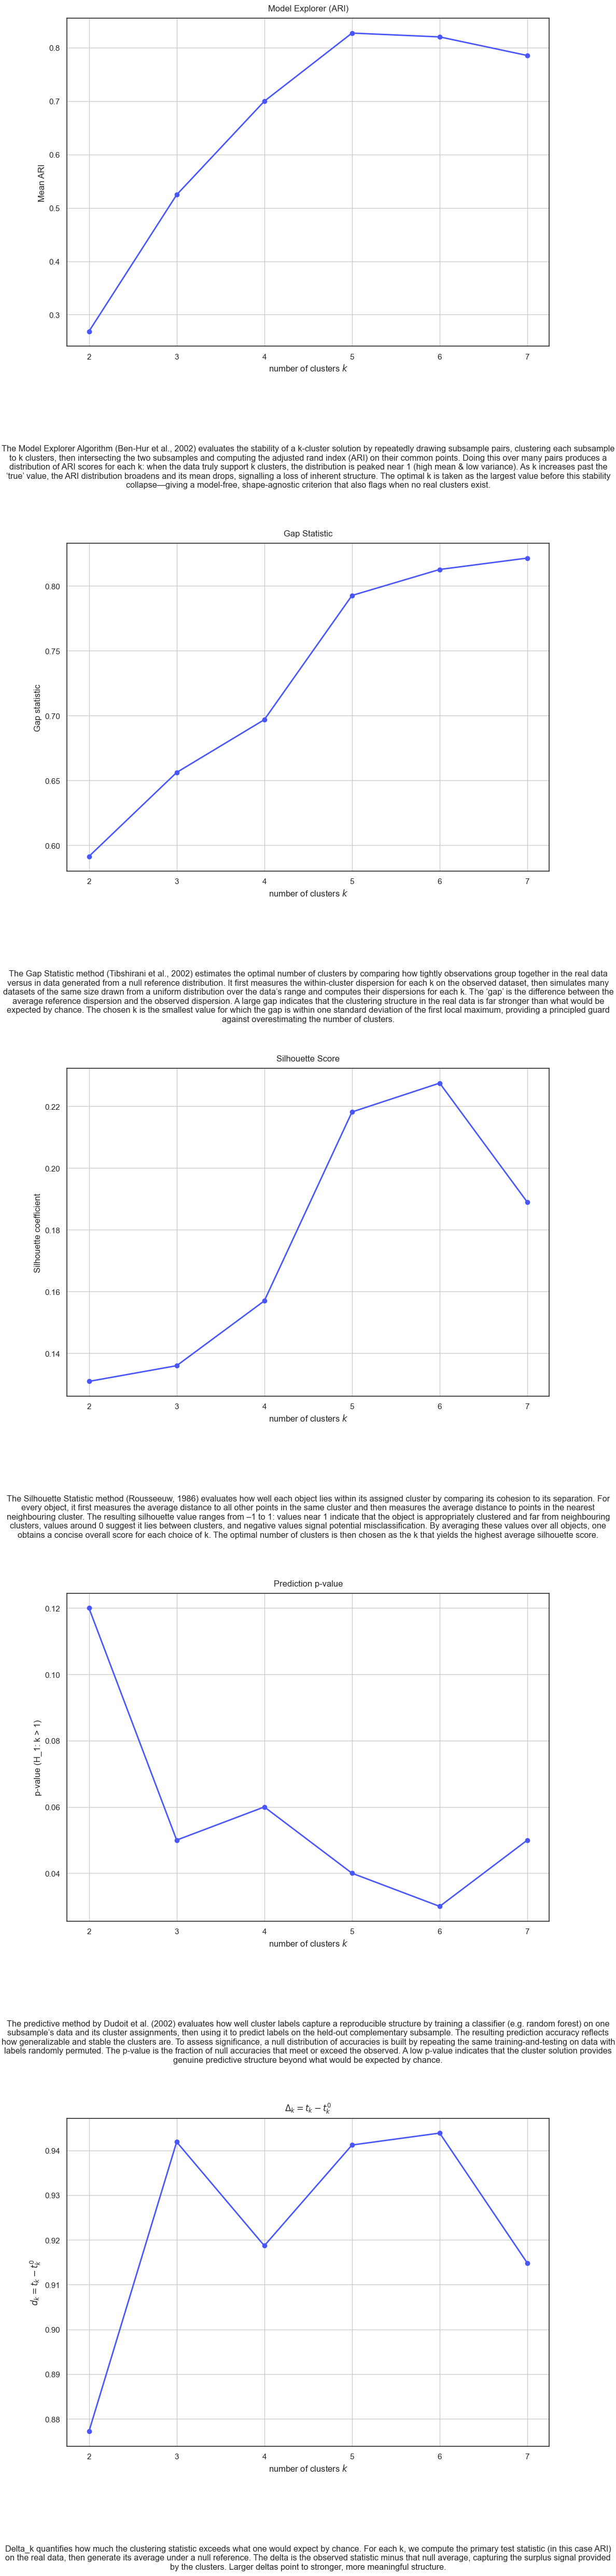

In [346]:
metrics = [
    (
        r"Model Explorer (ARI)",
        "model_explorer_ari",
        r"Mean ARI",
        "The Model Explorer Algorithm (Ben-Hur et al., 2002) evaluates the stability of a k-cluster solution by repeatedly drawing subsample pairs, clustering each subsample to k clusters, then intersecting the two subsamples and computing the adjusted rand index (ARI) on their common points. Doing this over many pairs produces a distribution of ARI scores for each k: when the data truly support k clusters, the distribution is peaked near 1 (high mean & low variance). As k increases past the ‘true’ value, the ARI distribution broadens and its mean drops, signalling a loss of inherent structure. The optimal k is taken as the largest value before this stability collapse—giving a model-free, shape-agnostic criterion that also flags when no real clusters exist."
    ),
    (
        r"Gap Statistic",
        "gap_score",
        r"Gap statistic",
        "The Gap Statistic method (Tibshirani et al., 2002) estimates the optimal number of clusters by comparing how tightly observations group together in the real data versus in data generated from a null reference distribution. It first measures the within-cluster dispersion for each k on the observed dataset, then simulates many datasets of the same size drawn from a uniform distribution over the data’s range and computes their dispersions for each k. The ‘gap’ is the difference between the average reference dispersion and the observed dispersion. A large gap indicates that the clustering structure in the real data is far stronger than what would be expected by chance. The chosen k is the smallest value for which the gap is within one standard deviation of the first local maximum, providing a principled guard against overestimating the number of clusters."
    ),
    (
        r"Silhouette Score",
        "silhouette_score",
        r"Silhouette coefficient",
        "The Silhouette Statistic method (Rousseeuw, 1986) evaluates how well each object lies within its assigned cluster by comparing its cohesion to its separation. For every object, it first measures the average distance to all other points in the same cluster and then measures the average distance to points in the nearest neighbouring cluster. The resulting silhouette value ranges from –1 to 1: values near 1 indicate that the object is appropriately clustered and far from neighbouring clusters, values around 0 suggest it lies between clusters, and negative values signal potential misclassification. By averaging these values over all objects, one obtains a concise overall score for each choice of k. The optimal number of clusters is then chosen as the k that yields the highest average silhouette score."
    ),
    (
        r"Prediction p-value",
        "pred_p_val",
        r"p-value (H_1: k > 1)",
        "The predictive method by Dudoit et al. (2002) evaluates how well cluster labels capture a reproducible structure by training a classifier (e.g. random forest) on one subsample’s data and its cluster assignments, then using it to predict labels on the held-out complementary subsample. The resulting prediction accuracy reflects how generalizable and stable the clusters are. To assess significance, a null distribution of accuracies is built by repeating the same training-and-testing on data with labels randomly permuted. The p-value is the fraction of null accuracies that meet or exceed the observed. A low p-value indicates that the cluster solution provides genuine predictive structure beyond what would be expected by chance."
    ),
    (
        r"$\Delta_k = t_k - t_k^0$",
        "pred_delta_k",
        r"$d_k = t_k - t_k^0$",
        "Delta_k quantifies how much the clustering statistic exceeds what one would expect by chance. For each k, we compute the primary test statistic (in this case ARI) on the real data, then generate its average under a null reference. The delta is the observed statistic minus that null average, capturing the surplus signal provided by the clusters. Larger deltas point to stronger, more meaningful structure."
    ),
]

n = len(metrics)

fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 12 * n))

for ax, (title, stat_key, ylbl, desc) in zip(axes, metrics):
    ks = sorted(results_by_k.keys())
    means = [results_by_k[k]["stats"][stat_key] for k in ks]

    ax.errorbar(ks, means, fmt="-o")
    ax.set_title(title, pad=10)
    ax.set_xlabel("number of clusters $k$")
    ax.set_ylabel(ylbl)

    ax.text(
        0.5,
        -0.3,
        desc,
        transform=ax.transAxes,
        ha="center",
        va="top",
        wrap=True,
        fontsize="small"
    )

plt.subplots_adjust(hspace=0.6, bottom=0.1)
plt.show()

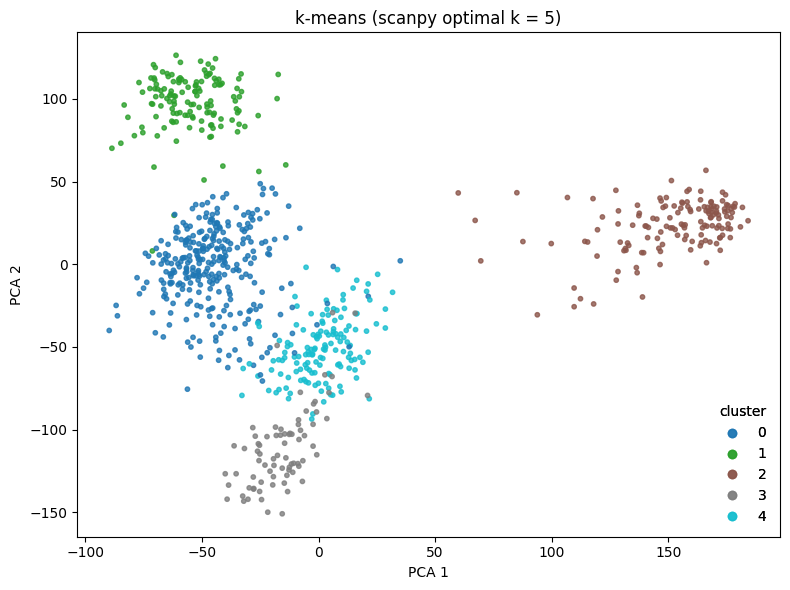

In [83]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X)

k = 5
kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED)
clusters = kmeans.fit_predict(X)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=clusters,
    s=10,
    alpha=0.8,
    cmap='tab10'
)
ax.set_title(f'k-means (scanpy optimal k = {k})')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')

legend1 = ax.legend(
    *scatter.legend_elements(),
    title="cluster",
    loc='lower right',
    frameon=False
)
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

In [75]:
# means = [results_by_k[k]['stats']['model_explorer_ari'] for k in ks]

# plt.errorbar(ks, means, fmt='-o')
# plt.xlabel('number of clusters k')
# plt.ylabel('mean ARI')
# plt.title('Model Explorer ARI curve (higher is better)')
# plt.show()

In [76]:
# means = [results_by_k[k]['stats']['gap_score'] for k in ks]

# plt.errorbar(ks, means, fmt='-o')
# plt.xlabel('number of clusters k')
# plt.ylabel('mean gap score')
# plt.title('gap statistic curve (higher is better)')
# plt.show()

In [77]:
# means = [results_by_k[k]['stats']['silhouette_score'] for k in ks]

# plt.errorbar(ks, means, fmt='-o')
# plt.xlabel('number of clusters k')
# plt.ylabel('mean silhouette score')
# plt.title('silhouette statistic curve (higher is better)')
# plt.show()

In [78]:
# means = [results_by_k[k]['stats']['pred_ari'] for k in ks]

# plt.errorbar(ks, means, fmt='-o')
# plt.xlabel('number of clusters k')
# plt.ylabel('median predictive ARI')
# plt.title('median of predictive ARIs (higher is better)')
# plt.show()

In [79]:
# means = [results_by_k[k]['stats']['pred_p_val'] for k in ks]

# plt.errorbar(ks, means, fmt='-o')
# plt.xlabel('number of clusters k')
# plt.ylabel('p-value (H_A: k > 1)')
# plt.title('p-value (H_A: k > 1) (lower is better)')
# plt.show()

In [80]:
# means = [results_by_k[k]['stats']['pred_delta_k'] for k in ks]

# plt.errorbar(ks, means, fmt='-o')
# plt.xlabel('number of clusters k')
# plt.ylabel('d_k = t_k - t_k^0')
# plt.title('d_k = t_k - t_k^0 (higher is better)')
# plt.show()

Exception ignored in: <function ResourceTracker.__del__ at 0x106279620>
Traceback (most recent call last):
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105969620>
Traceback (most recent call last):
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
Chi

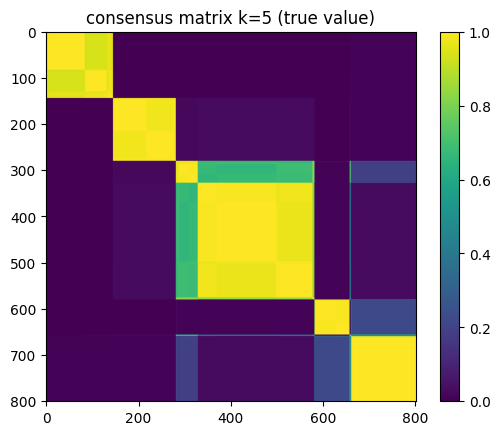

In [32]:
cons_matrix = results_by_k[5]['C']

plt.imshow(cons_matrix, aspect='equal')
plt.colorbar()
plt.title('consensus matrix k=5 (true value)')
plt.show()

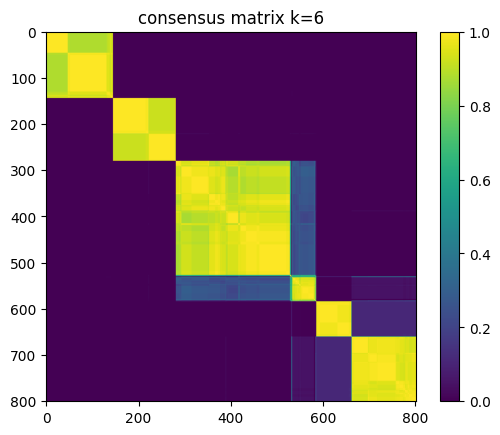

In [33]:
k_vis = 6

cons_matrix = results_by_k[k_vis]['C']

plt.imshow(cons_matrix, aspect='equal')
plt.colorbar()
plt.title(f'consensus matrix k={k_vis}')
plt.show()